# Проверка гипотез

## Цель

Проверить статистические гипотезы о данных Superstore.  
Определить, какие различия между группами и связи между переменными являются статистически значимыми, а какие - случайными.

## Гипотезы

### 1. Средний чек в Technology выше, чем в Furniture
- **H₀:** Средний чек в Technology равен среднему чеку в Furniture.
- **H₁:** Средний чек в Technology выше, чем в Furniture.
- **Тест:** t-тест.

### 2. Продажи различаются по регионам
- **H₀:** Средние продажи одинаковы во всех четырёх регионах (West, East, Central, South).
- **H₁:** Хотя бы один регион отличается по средним продажам.
- **Тест:** ANOVA.

### 3. Сегмент связан с категорией
- **H₀:** Сегмент (Consumer, Corporate, Home Office) и категория (Furniture, Office Supplies, Technology) независимы.
- **H₁:** Есть связь между сегментом и категорией.
- **Тест:** Хи-квадрат (χ²).

### 4. День заказа связан с типом доставки
- **H₀:** День недели заказа и тип доставки независимы.
- **H₁:** Есть связь между днём заказа и типом доставки.
- **Тест:** Хи-квадрат (χ²).

### 5. Тип доставки связан с регионом
- **H₀:** Тип доставки и регион независимы.
- **H₁:** Есть связь между типом доставки и регионом.
- **Тест:** Хи-квадрат (χ²).

### 6. Сегмент связан со средним чеком
- **H₀:** Средний чек одинаков во всех трёх сегментах (Consumer, Corporate, Home Office).
- **H₁:** Хотя бы один сегмент отличается по среднему чеку.
- **Тест:** ANOVA.

### 7. Категория связана с месяцем заказа
- **H₀:** Категория и месяц заказа независимы.
- **H₁:** Есть связь между категорией и месяцем заказа.
- **Тест:** Хи-квадрат (χ²).

## Данные

- **Файл:** `data/processed/superstore_clean.csv`
- **Строк:** 9789
- **Колонок:** 24

In [29]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/superstore_clean.csv', parse_dates=['Order Date', 'Ship Date'])
print(df.head())
print(df.info())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookcases   
1        Furniture        Chairs

### Гипотеза 1: Средний чек в Technology выше, чем в Furniture

**H₀:** Средний чек в Technology равен среднему чеку в Furniture.  

**H₁:** Средний чек в Technology выше, чем в Furniture.

**Тест:** t-тест для независимых выборок (Уэлч, если дисперсии различаются).

In [3]:
tech = df[df['Category'] == 'Technology']['Sales']
furn = df[df['Category'] == 'Furniture']['Sales']

levene_stat, levene_p = stats.levene(tech, furn)
print(f"Levene p-value: {levene_p:.4f}")

if levene_p > 0.05:
    equal_var_value = True
else:
    equal_var_value = False
t_stat, p_value = stats.ttest_ind(tech, furn, equal_var = equal_var_value)
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Разница статистически значима: Technology > Furniture")
else:
    print("Разница не значима")

print(f"Средний чек Technology: {tech.mean():.2f}")
print(f"Средний чек Furniture: {furn.mean():.2f}")
print(f"Разница: {tech.mean() - furn.mean():.2f}")

Levene p-value: 0.0002
t-статистика: 3.7920
p-value: 0.000153
Разница статистически значима: Technology > Furniture
Средний чек Technology: 456.27
Средний чек Furniture: 348.53
Разница: 107.75


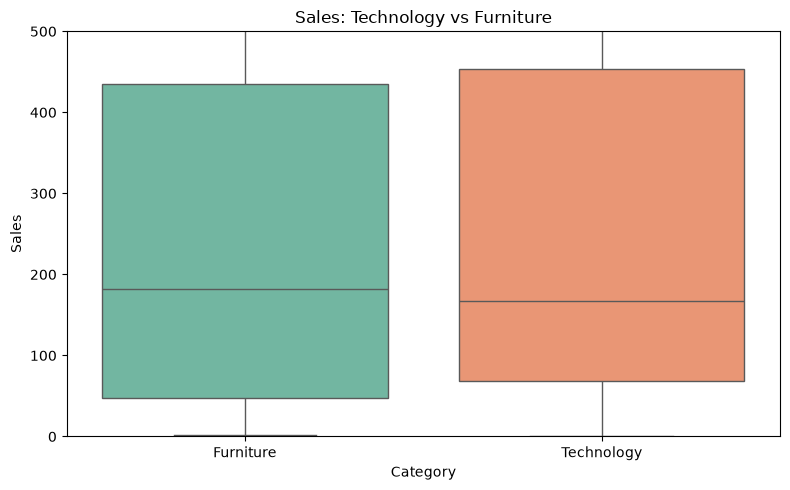

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['Category'].isin(['Technology', 'Furniture'])], x='Category', y='Sales', hue='Category', palette='Set2', legend=False)
plt.ylim(0, 500)
plt.title('Sales: Technology vs Furniture')
plt.tight_layout()
plt.savefig('../reports/figures/14_sales_tech_vs_furn.png', dpi=100, bbox_inches='tight')
plt.show()

### Гипотеза 1: Средний чек в Technology выше, чем в Furniture

**H₀:** Средний чек в Technology равен среднему чеку в Furniture.  
**H₁:** Средний чек в Technology выше, чем в Furniture.

**Тест:** t-тест Уэлча (дисперсии различаются: Левен p = 0.0002).

**Результат:**
- t-статистика: 3.7920
- p-value: 0.000153
- Средний чек Technology: 456.27
- Средний чек Furniture: 348.53
- Разница: 107.75

**Вывод:**
разница статистически значима (p < 0.001). Средний чек в Technology статистически значимо выше, чем в Furniture. Это подтверждает, что Technology - более дорогая категория, и бизнесу стоит фокусироваться на ней для увеличения выручки.

### Гипотеза 2: Продажи различаются по регионам

**H₀:** Средние продажи одинаковы во всех четырёх регионах (West, East, Central, South).

**H₁:** Хотя бы один регион отличается по средним продажам.

**Тест:** ANOVA (однофакторный).

In [5]:
west = df[df['Region'] == 'West']['Sales']
east = df[df['Region'] == 'East']['Sales']
central = df[df['Region'] == 'Central']['Sales']
south = df[df['Region'] == 'South']['Sales']

levene_stat, levene_p = stats.levene(west, east, central, south)
print(f"Levene p-value: {levene_p:.4f}")

if levene_p > 0.05:
    print("Дисперсии равны - классический ANOVA")
    f_stat, p_value = stats.f_oneway(west, east, central, south)
    print(f"F-статистика: {f_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
else:
    print("Дисперсии НЕ равны - Kruskal-Wallis (непараметрический ANOVA)")
    h_stat, p_value = stats.kruskal(west, east, central, south)
    print(f"H-статистика: {h_stat:.4f}")
    print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Разница статистически значима: продажи различаются по регионам")
else:
    print("Разница не значима: продажи одинаковы во всех регионах")

Levene p-value: 0.5369
Дисперсии равны - классический ANOVA
F-статистика: 0.8058
p-value: 0.490447
Разница не значима: продажи одинаковы во всех регионах


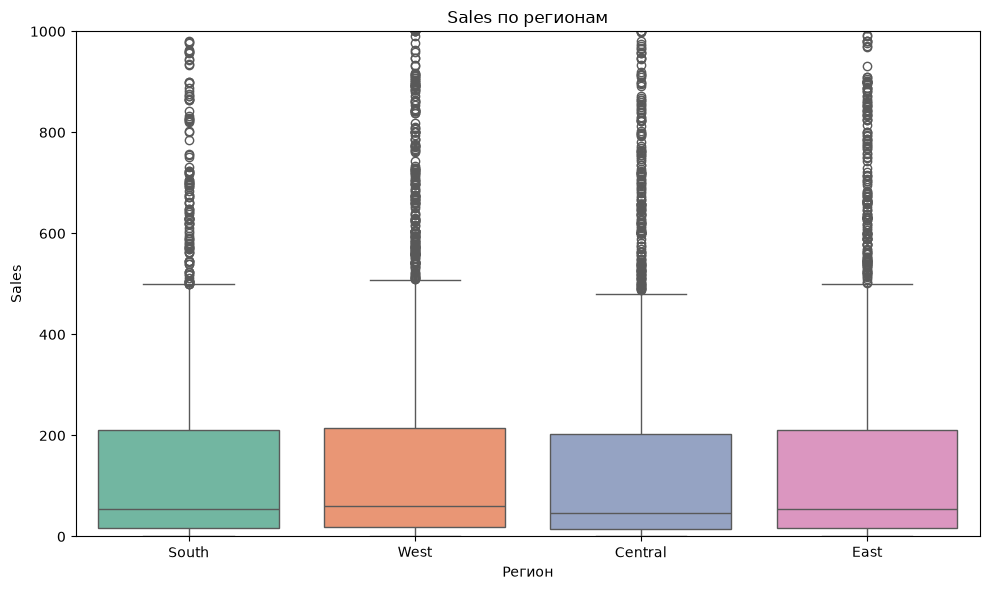

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Region', y='Sales', hue='Region', palette='Set2', legend=False)
plt.ylim(0, 1000)
plt.title('Sales по регионам')
plt.xlabel('Регион')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../reports/figures/15_sales_by_region_box.png', dpi=100, bbox_inches='tight')
plt.show()

### Гипотеза 2: Продажи различаются по регионам

**H₀:** Средние продажи одинаковы во всех четырёх регионах (West, East, Central, South).  
**H₁:** Хотя бы один регион отличается по средним продажам.

**Тест:** ANOVA (дисперсии равны: Левен p = 0.5369).

**Результат:**
- F-статистика: 0.8058
- p-value: 0.490447

**Вывод:**
разница не значима (p > 0.05). Средние продажи статистически не различаются по регионам. Хотя West лидирует по сумме продаж (710 000), это обусловлено количеством заказов, а не размером среднего чека. Медианы чеков по регионам почти одинаковы.

### Гипотеза 3: Сегмент связан с категорией

**H₀:** Сегмент (Consumer, Corporate, Home Office) и категория (Furniture, Office Supplies, Technology) независимы. 
 
**H₁:** Есть связь между сегментом и категорией.

**Тест:** Хи-квадрат (χ²).

In [7]:
contingency = pd.crosstab(df['Segment'], df['Category'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Хи-квадрат: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Степени свободы: {dof}")

if p_value < 0.05:
    print('Статистически значимая связь. Между сегментами и категориями есть связь')
else:
    print('Нет статистической значимости')

print("Наблюдаемые:")
print(contingency)

print("\nОжидаемые (если бы связи не было):")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

Хи-квадрат: 1.0895
p-value: 0.895936
Степени свободы: 4
Нет статистической значимости
Наблюдаемые:
Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer          1092             3068         936
Corporate          627             1781         540
Home Office        357             1054         334

Ожидаемые (если бы связи не было):
Category       Furniture  Office Supplies  Technology
Segment                                              
Consumer     1080.733068      3073.009296  942.257636
Corporate     625.196445      1777.714169  545.089386
Home Office   370.070487      1052.276535  322.652978


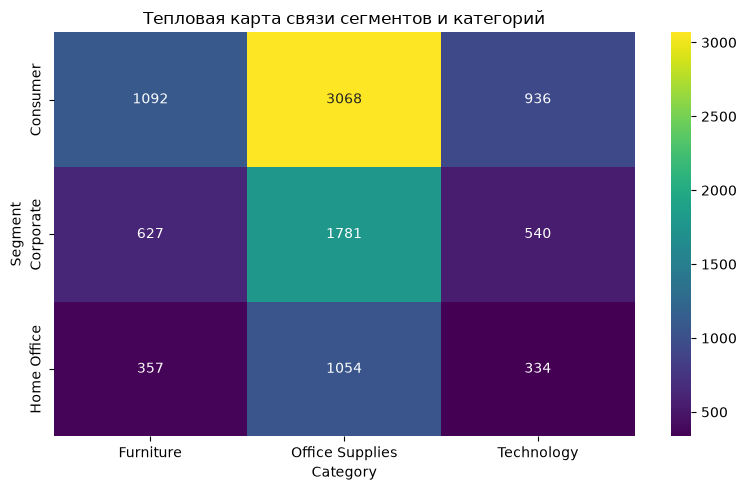

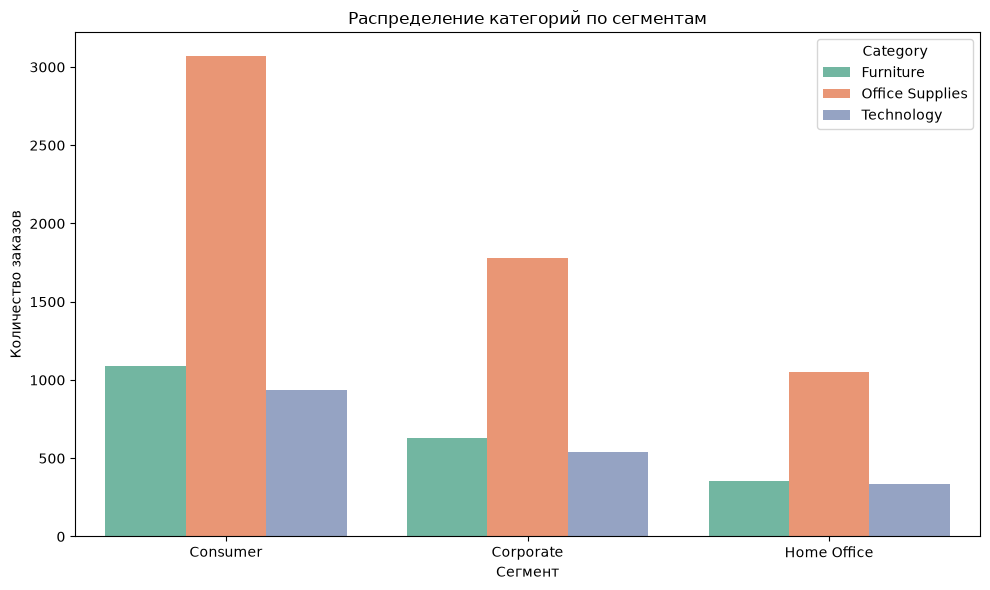

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(data=contingency, annot=True, fmt='d', cmap='viridis')
plt.title('Тепловая карта связи сегментов и категорий')
plt.tight_layout()
plt.savefig('../reports/figures/16_heatmap_segment_category.png', dpi=100, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Segment', hue='Category', palette='Set2')
plt.title('Распределение категорий по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.savefig('../reports/figures/17_countplot_segment_category.png', dpi=100, bbox_inches='tight')
plt.show()

### Гипотеза 3: Сегмент связан с категорией

**H₀:** Сегмент (Consumer, Corporate, Home Office) и категория (Furniture, Office Supplies, Technology) независимы.  
**H₁:** Есть связь между сегментом и категорией.

**Тест:** Хи-квадрат (χ²).

**Результат:**
- χ²: 1.0895
- p-value: 0.895936
- Степени свободы: 4

**Вывод:**
связь не значима (p > 0.05). Сегмент клиента не влияет на выбор категории товара. Consumer, Corporate и Home Office покупают Furniture, Office Supplies и Technology в одинаковых пропорциях. Маркетинговые кампании можно не сегментировать по категориям.

### Гипотеза 4: День заказа связан с типом доставки

**H₀:** День недели заказа и тип доставки независимы.  

**H₁:** Есть связь между днём заказа и типом доставки.

**Тест:** Хи-квадрат (χ²).

In [9]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Order Day of Week'] = pd.Categorical(df['Order Day of Week'], categories=order, ordered=True)

contingency = pd.crosstab(df['Order Day of Week'], df['Ship Mode'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Хи-квадрат: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Степени свободы: {dof}")

if p_value < 0.05:
    print('Статистически значимая связь. Между днями недели и типом доставки есть связь')
else:
    print('Нет статистической значимости')

print("Наблюдаемые:")
print(contingency)

print("\nОжидаемые (если бы связи не было):")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

Хи-квадрат: 77.6462
p-value: 0.000000
Степени свободы: 18
Статистически значимая связь. Между днями недели и типом доставки есть связь
Наблюдаемые:
Ship Mode          First Class  Same Day  Second Class  Standard Class
Order Day of Week                                                     
Monday                     289       109           352             839
Tuesday                    259       104           346            1179
Wednesday                  202        33           262             731
Thursday                    66        30           105             339
Friday                     188        62           193             620
Saturday                   262       108           322            1094
Sunday                     235        92           321            1047

Ожидаемые (если бы связи не было):
Ship Mode          First Class    Same Day  Second Class  Standard Class
Order Day of Week                                                       
Monday              243.649913 

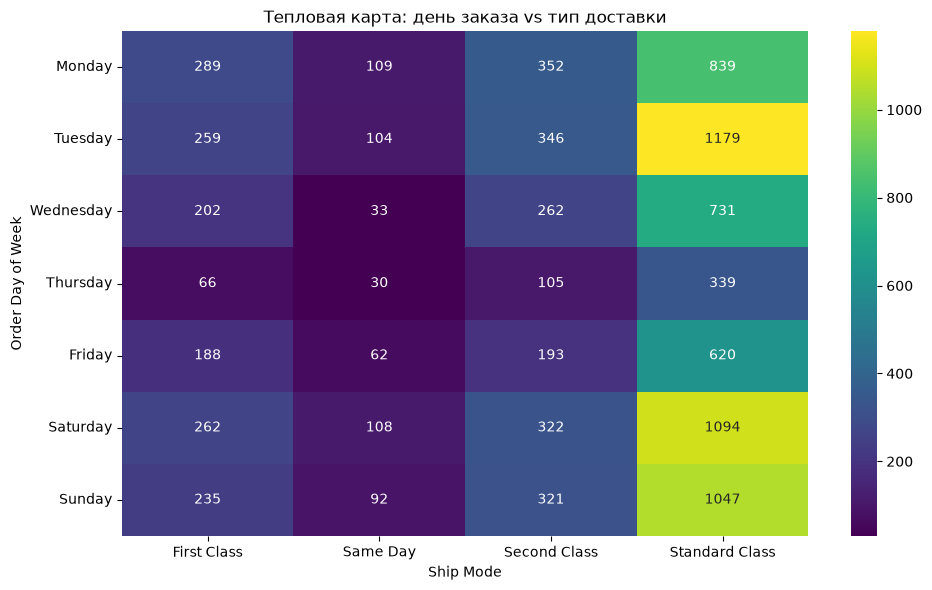

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=contingency, annot=True, fmt='d', cmap='viridis')
plt.title('Тепловая карта: день заказа vs тип доставки')
plt.tight_layout()
plt.savefig('../reports/figures/18_heatmap_day_shipmode.png', dpi=100, bbox_inches='tight')
plt.show()

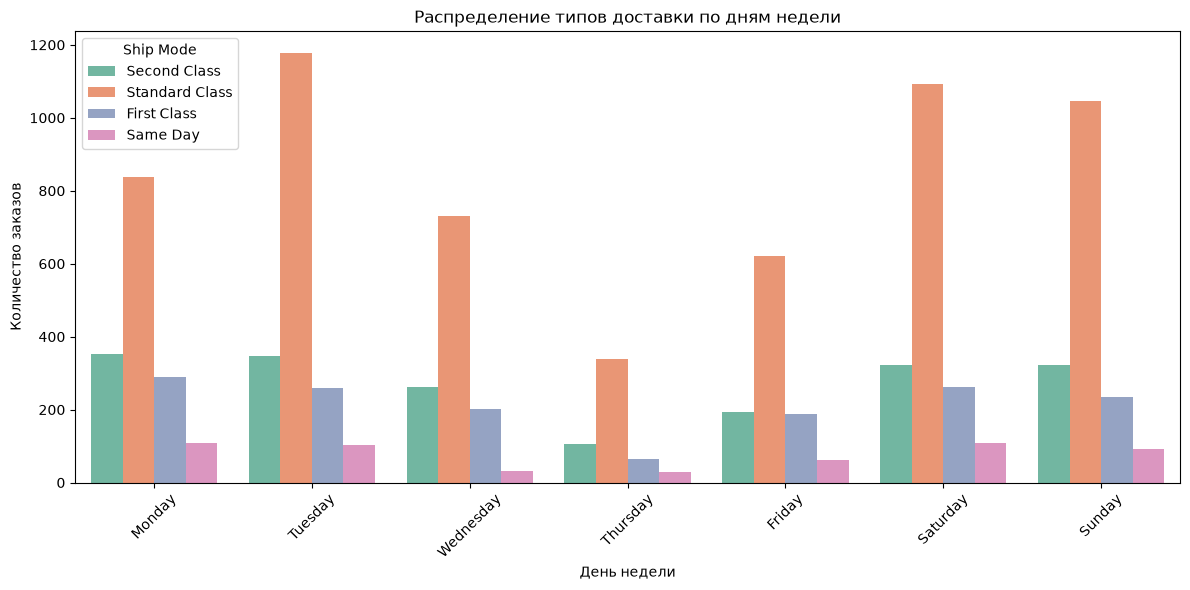

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Order Day of Week', hue='Ship Mode', palette='Set2')
plt.title('Распределение типов доставки по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/19_countplot_day_shipmode.png', dpi=100, bbox_inches='tight')
plt.show()

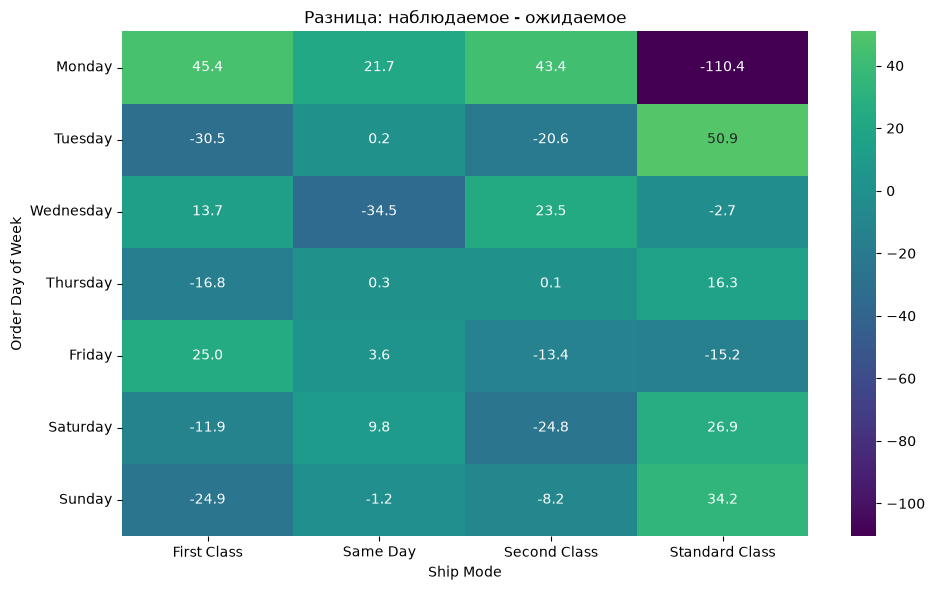

In [12]:
diff = contingency - expected
plt.figure(figsize=(10, 6))
sns.heatmap(data=diff, annot=True, fmt='.1f', cmap='viridis', center=0)
plt.title('Разница: наблюдаемое - ожидаемое')
plt.tight_layout()
plt.savefig('../reports/figures/20_heatmap_diff_day_shipmode.png', dpi=100, bbox_inches='tight')
plt.show()

### Гипотеза 4: День заказа связан с типом доставки

**H₀:** День недели заказа и тип доставки независимы.  
**H₁:** Есть связь между днём заказа и типом доставки.

**Тест:** Хи-квадрат (χ²).

**Результат:**
- χ²: 77.6462
- p-value: 0.000000
- Степени свободы: 18

**Вывод:**
связь статистически значима (p < 0.001). День недели влияет на выбор типа доставки.

**Что видно:**
- Standard Class - самый популярный тип доставки во все дни.
- Вторник - пик Standard Class (1179), но First Class ниже ожидаемого (-30.5).
- Четверг - провал по всем типам доставки.
- Понедельник - аномалия: First Class (+45.4) и Same Day (+21.7) выше ожидаемого, Standard Class ниже ожидаемого (-110.4).
- Суббота - Same Day выше ожидаемого (+9.8).

**Бизнес-интерпретация:**
- В понедельник клиенты торопятся - выбирают быстрые доставки.
- В четверг заказов мало - можно оптимизировать логистику.
- В субботу есть спрос на срочную доставку.

**Рекомендация:**
- В будни (вторник-четверг) - стимулировать First Class и Same Day скидками.
- В понедельник - увеличить ресурсы на быструю доставку.
- В четверг - снизить операционные расходы.

### Гипотеза 5: Тип доставки связан с регионом

**H₀:** Тип доставки и регион независимы.  

**H₁:** Есть связь между типом доставки и регионом.

**Тест:** Хи-квадрат (χ²).

**Бизнес-смысл:**  
Проверить, выбирают ли клиенты в разных регионах разные типы доставки.  
Например, в богатых регионах (West, East) могут чаще выбирать First Class, а в Central и South - Standard Class.

In [13]:
contingency = pd.crosstab(df['Ship Mode'], df['Region'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Хи-квадрат: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Степени свободы: {dof}")

if p_value < 0.05:
    print('Связь между типом доставки и регионом статистически значима')
else:
    print('Связь не значима статистически - тип доставки не зависит от региона')

print("Наблюдаемые:")
print(contingency)

print("Ожидаемые:")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

Хи-квадрат: 22.5264
p-value: 0.007352
Степени свободы: 9
Связь между типом доставки и регионом статистически значима
Наблюдаемые:
Region          Central  East  South  West
Ship Mode                                 
First Class         292   470    232   507
Same Day            118   154     83   183
Second Class        447   520    325   609
Standard Class     1420  1630    958  1841
Ожидаемые:
Region              Central         East       South         West
Ship Mode                                                        
First Class      349.144652   425.352334  245.029932   481.473082
Same Day         125.143120   152.458065   87.825518   172.573297
Second Class     442.187864   538.704056  310.327715   609.780366
Standard Class  1360.524364  1657.485545  954.816835  1876.173256


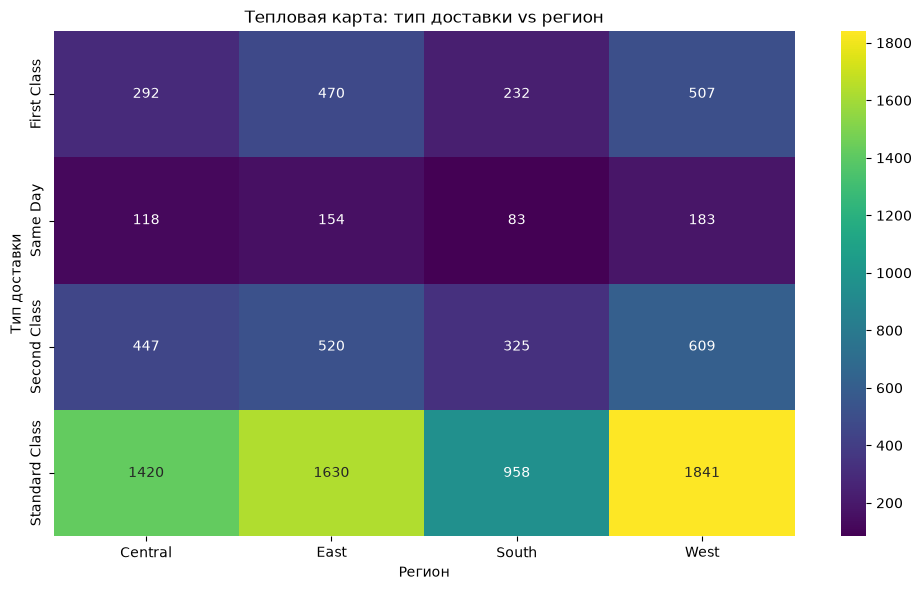

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(data=contingency, annot=True, fmt='d', cmap='viridis')
plt.title('Тепловая карта: тип доставки vs регион')
plt.xlabel('Регион')
plt.ylabel('Тип доставки')
plt.tight_layout()
plt.savefig('../reports/figures/21_heatmap_region_shipmode.png', dpi=100, bbox_inches='tight')
plt.show()

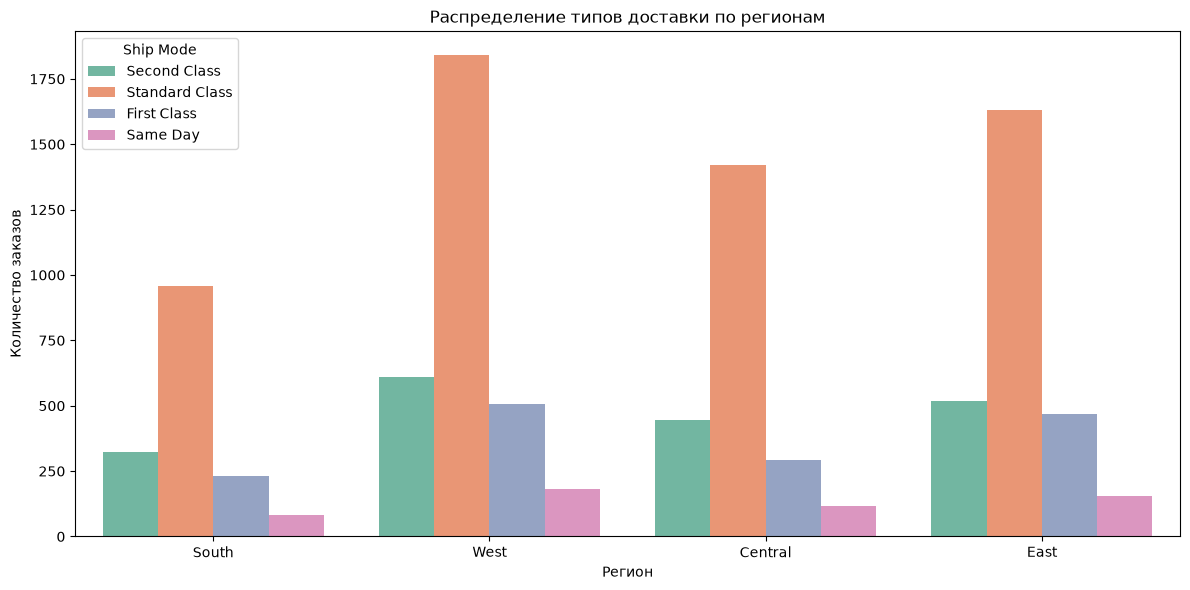

In [15]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Region', hue='Ship Mode', palette='Set2')
plt.title('Распределение типов доставки по регионам')
plt.xlabel('Регион')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.savefig('../reports/figures/22_countplot_region_shipmode.png', dpi=100, bbox_inches='tight')
plt.show()

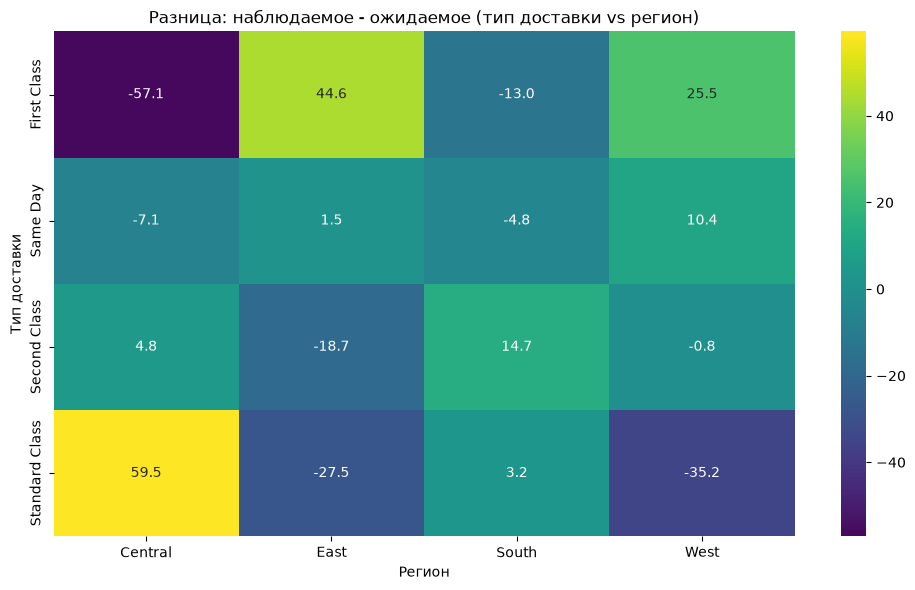

In [16]:
diff = contingency - expected
plt.figure(figsize=(10, 6))
sns.heatmap(data=diff, annot=True, fmt='.1f', cmap='viridis', center=0)
plt.title('Разница: наблюдаемое - ожидаемое (тип доставки vs регион)')
plt.xlabel('Регион')
plt.ylabel('Тип доставки')
plt.tight_layout()
plt.savefig('../reports/figures/23_heatmap_diff_region_shipmode.png', dpi=100, bbox_inches='tight')
plt.show()

### Гипотеза 5: Тип доставки связан с регионом

**H₀:** Тип доставки и регион независимы.  
**H₁:** Есть связь между типом доставки и регионом.

**Тест:** Хи-квадрат (χ²).

**Результат:**
- χ²: 22.5264
- p-value: 0.007352
- Степени свободы: 9

**Вывод:**
Связь статистически значима (p < 0.05). Тип доставки зависит от региона.

**Что видно:**
- Standard Class доминирует во всех регионах.
- First Class в Central ниже ожидаемого (−57), в West выше ожидаемого (+26).
- Same Day в East и West близок к ожидаемому, в Central и South - чуть ниже.
- South - самый слабый регион по всем типам доставки.

**Бизнес-интерпретация:**
- В West и East клиенты чаще выбирают First Class - регионы более платёжеспособны.
- В Central и South преобладает Standard Class - клиенты экономят на доставке.
- South - самый слабый регион: меньше заказов, меньше срочных доставок.

**Рекомендация:**
- В West и East - поддерживать и развивать First Class (спрос есть).
- В Central и South - стимулировать First Class скидками, чтобы повысить средний чек.
- В South - увеличить маркетинговую активность: регион недополучает заказы.

### Гипотеза 6: Сегмент связан со средним чеком

**H₀:** Средний чек одинаков во всех трёх сегментах (Consumer, Corporate, Home Office).
  
**H₁:** Хотя бы один сегмент отличается по среднему чеку.

**Тест:** ANOVA (однофакторный). Если дисперсии различаются - Kruskal-Wallis.

**Бизнес-смысл:**  
Проверить, тратят ли клиенты из разных сегментов разные суммы.  
Например, Corporate может закупать больше, чем Consumer.

In [38]:
consumer = df[df['Segment'] == 'Consumer']['Sales']
corporate = df[df['Segment'] == 'Corporate']['Sales']
home_office = df[df['Segment'] == 'Home Office']['Sales']

levene_stat, levene_p = stats.levene(consumer, corporate, home_office)
print(f"Levene p-value: {levene_p:.4f}")

if levene_p > 0.05:
    print('Дисперсии равны - ANOVA')
    f_stat, p_value = stats.f_oneway(consumer, corporate, home_office)
    print(f"F-статистика: {f_stat:.4f}")
else:
    print('Дисперсии не равны - Kruskal-Wallis')
    h_stat, p_value = stats.kruskal(consumer, corporate, home_office)
    print(f"H-статистика: {h_stat:.4f}")

print(f"\np-value: {p_value:.6f}")

if p_value < 0.05:
    print("Отличие статистически значимо - сегменты отличаются по среднему чеку")
else:
    print('Разница не значима: средний чек одинаков во всех сегментах')

print('\nСредние значения чеков:')
print(f"Consumer: {consumer.mean()}")
print(f"Corporate: {corporate.mean()}")
print(f"Home Office : {home_office.mean()}")

Levene p-value: 0.5616
Дисперсии равны - ANOVA
F-статистика: 0.5345

p-value: 0.585973
Разница не значима: средний чек одинаков во всех сегментах

Средние значения чеков:
Consumer: 225.02122272370488
Corporate: 231.41514070556312
Home Office : 242.8008177077364


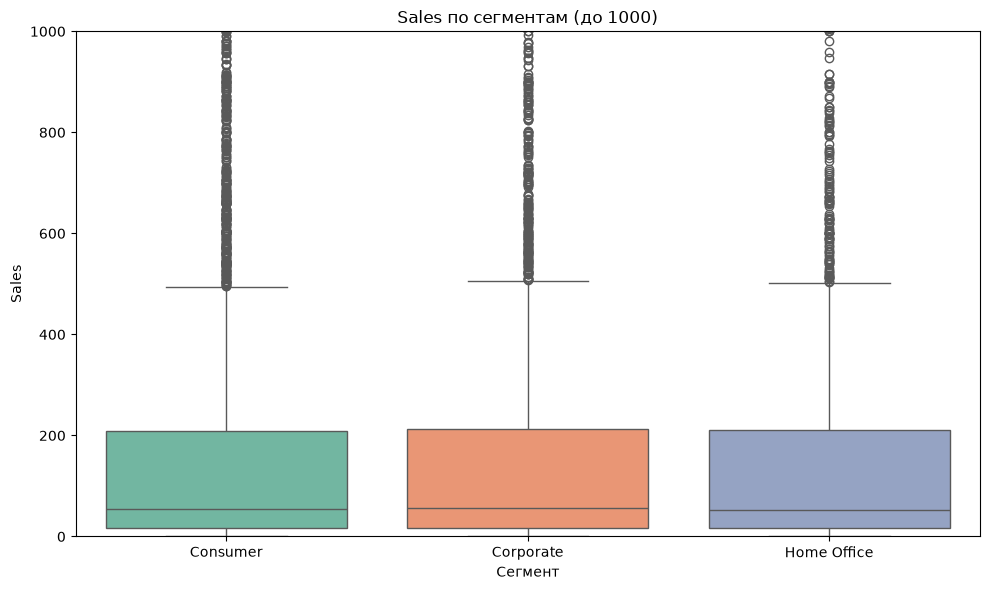

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Segment', y='Sales', hue='Segment', palette='Set2', legend=False)
plt.ylim(0, 1000)
plt.title('Sales по сегментам (до 1000)')
plt.xlabel('Сегмент')
plt.ylabel('Sales')
plt.tight_layout()
plt.savefig('../reports/figures/24_box_sales_segment.png', dpi=100, bbox_inches='tight')
plt.show()

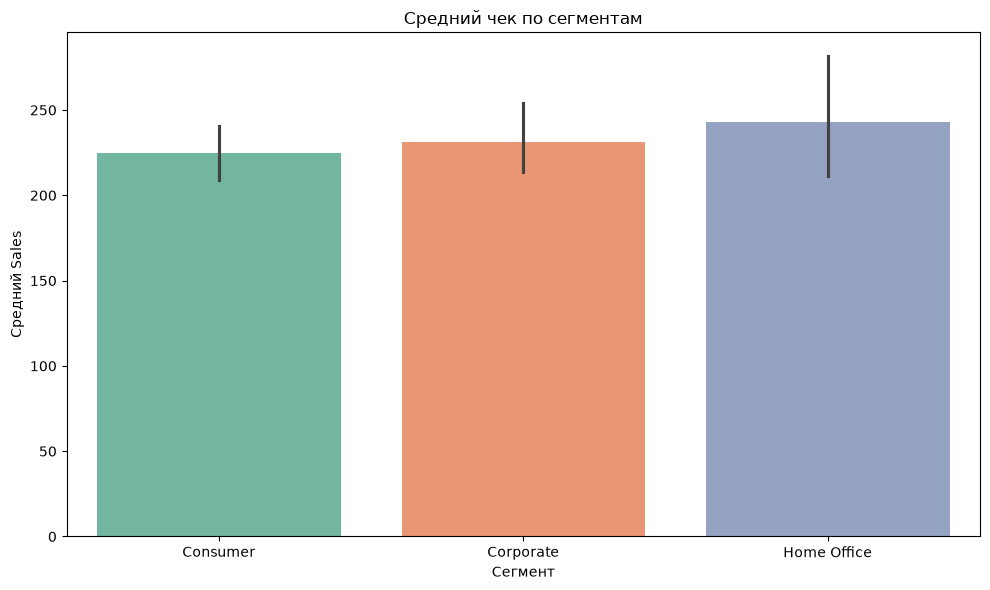

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Segment', y='Sales', estimator='mean',
            hue='Segment', palette='Set2', legend=False)
plt.title('Средний чек по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Средний Sales')
plt.tight_layout()
plt.savefig('../reports/figures/25_bar_avg_segment.png', dpi=100, bbox_inches='tight')
plt.show()

### Гипотеза 6: Сегмент связан со средним чеком

**H₀:** Средний чек одинаков во всех трёх сегментах (Consumer, Corporate, Home Office).  
**H₁:** Хотя бы один сегмент отличается по среднему чеку.

**Тест:** ANOVA (дисперсии равны: Levene p = 0.5616).

**Результат:**
- F-статистика: 0.5345
- p-value: 0.585973
- Consumer: 225.02
- Corporate: 231.42
- Home Office: 242.80

**Вывод:**
разница не значима (p > 0.05). Средний чек статистически не различается между сегментами. Consumer, Corporate и Home Office тратят примерно одинаково. Различия в сумме продаж по сегментам обусловлены количеством заказов, а не размером чека.

**Бизнес-интерпретация:**
сегмент клиента не влияет на размер среднего чека. Бизнесу не нужно разрабатывать отдельные стратегии для каждого сегмента по размеру чека - можно фокусироваться на увеличении количества заказов во всех сегментах одновременно.

### Гипотеза 7: Категория связана с месяцем заказа

**H₀:** Категория и месяц заказа независимы.  

**H₁:** Есть связь между категорией и месяцем заказа.

**Тест:** Хи-квадрат (χ²).

**Бизнес-смысл:**  
Проверить, есть ли у категорий сезонность.  
Например, Technology может покупаться в декабре, Furniture - летом.

In [ ]:
contingency = pd.crosstab(df['Category'], df['Order Month'])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"Хи-квадрат: {chi2:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Степени свободы: {dof}")

if p_value < 0.05:
    print("Связь статистически значима: категория зависит от месяца")
else:
    print("Связи нет: категория не зависит от месяца")

Хи-квадрат: 25.5122
p-value: 0.273212
Степени свободы: 22
Связи нет: категория не зависит от месяца.


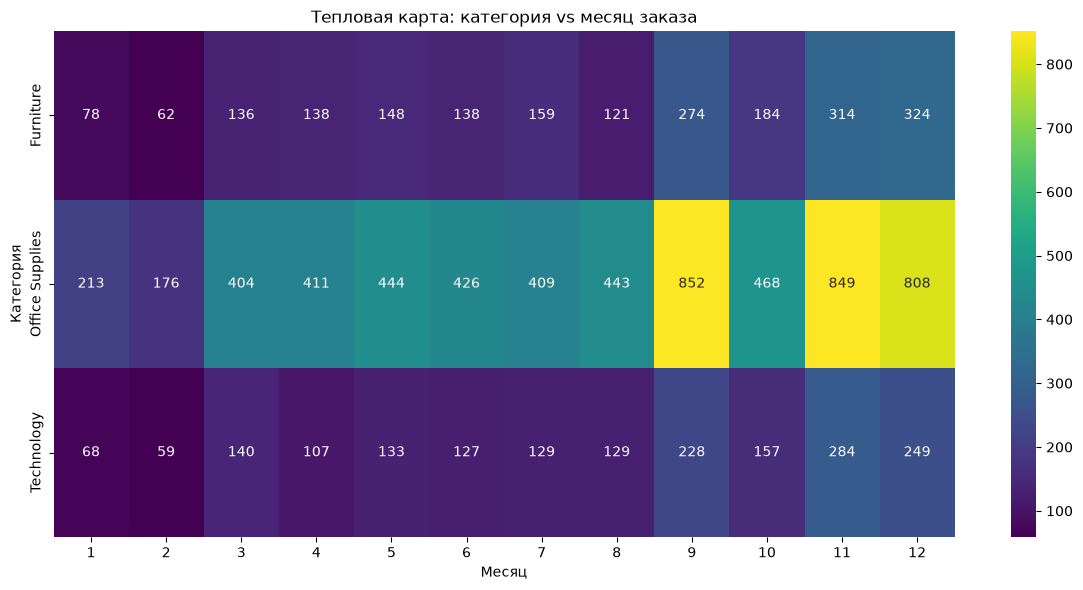

In [40]:
plt.figure(figsize=(12, 6))
sns.heatmap(data=contingency, annot=True, fmt='d', cmap='viridis')
plt.title('Тепловая карта: категория vs месяц заказа')
plt.xlabel('Месяц')
plt.ylabel('Категория')
plt.tight_layout()
plt.savefig('../reports/figures/26_heatmap_category_month.png', dpi=100, bbox_inches='tight')
plt.show()

### Гипотеза 7: Категория связана с месяцем заказа

**H₀:** Категория и месяц заказа независимы.  
**H₁:** Есть связь между категорией и месяцем заказа.

**Тест:** Хи-квадрат (χ²).

**Результат:**
- χ²: 25.5122
- p-value: 0.273212
- Степени свободы: 22

**Вывод:**
связь статистически не значима (p > 0.05). Категория не зависит от месяца заказа.

**Однако:** на тепловой карте видна **визуальная аномалия** - Office Supplies резко возрастает в сентябре (852), ноябре (849) и декабре (808). Это может указывать на **слабую сезонность** в Office Supplies, но χ² не подтверждает её статистически из-за большого числа степеней свободы (22) и размытия картины другими категориями.

**Рекомендация:**
провести **отдельный анализ** для Office Supplies: сравнить продажи в сентябре–декабре с остальными месяцами через t-тест или ANOVA. Возможно, сезонность **есть**, но её **не видно** в общей картине.

In [47]:
office = df[df['Category'] == 'Office Supplies']

high_season = office[office['Order Month'].isin([9, 10, 11, 12])]['Sales']
low_season = office[~office['Order Month'].isin([9, 10, 11, 12])]['Sales']

print("Средний чек:")
print(f"Высокий сезон (9-12): {high_season.mean():.2f}")
print(f"Низкий сезон (1-8): {low_season.mean():.2f}")

t_stat, p_value = stats.ttest_ind(high_season, low_season, equal_var=False)
print(f"\nt-тест (средний чек): t = {t_stat:.4f}, p = {p_value:.6f}")

if p_value < 0.05:
    print("Средний чек статистически значимо отличается по сезонам")
else:
    print("Средний чек не зависит от сезона")

monthly_counts = office.groupby('Order Month')['Order ID'].nunique()
high_count = monthly_counts[monthly_counts.index.isin([9, 10, 11, 12])].sum()
low_count = monthly_counts[~monthly_counts.index.isin([9, 10, 11, 12])].sum()

print(f"\nКоличество заказов:")
print(f"Высокий сезон (9-12): {high_count}")
print(f"Низкий сезон (1-8): {low_count}")
print(f"Разница: {high_count - low_count}")

monthly_share = df.groupby(['Order Month', 'Category']).size().unstack()
monthly_share_pct = monthly_share.div(monthly_share.sum(axis=1), axis=0) * 100
print("\nДоля категорий по месяцам (%):")
print(monthly_share_pct.round(2))

Средний чек:
Высокий сезон (9-12): 119.27
Низкий сезон (1-8): 118.99

t-тест (средний чек): t = 0.0280, p = 0.977680
Средний чек не зависит от сезона

Количество заказов:
Высокий сезон (9-12): 1870
Низкий сезон (1-8): 1804
Разница: 66

Доля категорий по месяцам (%):
Category     Furniture  Office Supplies  Technology
Order Month                                        
1                21.73            59.33       18.94
2                20.88            59.26       19.87
3                20.00            59.41       20.59
4                21.04            62.65       16.31
5                20.41            61.24       18.34
6                19.97            61.65       18.38
7                22.81            58.68       18.51
8                17.46            63.92       18.61
9                20.24            62.92       16.84
10               22.74            57.85       19.41
11               21.70            58.67       19.63
12               23.46            58.51       18.03


### Дополнительный анализ: сезонность в Office Supplies

**Проверка:** сравнили средний чек и количество заказов в высокий сезон (сентябрь-декабрь) и низкий (январь-август).

**Результат:**
- Средний чек: t = 0.028, p = 0.98 - не значимо.
- Количество заказов: 1870 (высокий) vs 1804 (низкий) - +3.6%.
- Доля Office Supplies по месяцам: 58–64% - стабильна.

**Вывод:**
сезонность в Office Supplies **не подтверждается**. Пик на тепловой карте объясняется **общим ростом** всех категорий в конце года, а не спецификой Office Supplies. Средний чек не меняется, количество заказов растёт незначительно, доля категории стабильна.